In [ ]:
!pip install astropy

Merge de bins

In [2]:
from astropy.table import Table, vstack
import os

INPUT_DIR = "/content"

files = sorted([
    os.path.join(INPUT_DIR, f)
    for f in os.listdir(INPUT_DIR)
    if f.endswith(".fits") and f.startswith("bin_")
])

if len(files) == 0:
    raise RuntimeError("No se encontraron bins")

bin_sizes = []

tables = []

for f in files:
    t = Table.read(f)
    n = len(t)
    bin_sizes.append(n)
    tables.append(t)

total_bins = sum(bin_sizes)

print("Suma total de bins:", total_bins)

print("Haciendo merge")
full = vstack(tables)

merge_size = len(full)

print("Tamaño del merge:", merge_size)

print("Checkeo de cantidad de filas:")

if total_bins == merge_size:
    print("Ok (suma de bins = merge)")
    # Guardar el merge completo en FITS
    output_path = os.path.join(INPUT_DIR, "gaia_merge.fits")
    full.write(output_path, overwrite=True)
    print(f"Merge guardado en: {output_path}")
else:
    print("DIFERENCIA DETECTADA")
    print("Diff:", merge_size - total_bins)

Suma total de bins: 2804462
Haciendo merge
Tamaño del merge: 2804462
Checkeo de cantidad de filas:
Ok (suma de bins = merge)
Merge guardado en: /content/gaia_merge.fits


In [3]:
gaia = Table.read("/content/gaia_merge.fits")

Convertir magnitud Gaia --> CD

In [4]:
import numpy as np

def agregar_magnitud_cd_estimada(gaia):

    G  = np.array(gaia['phot_g_mean_mag'], dtype=float)

    if 'bp_rp' in gaia.colnames:
        bp_rp = np.array(gaia['bp_rp'], dtype=float)
    else:
        bp_rp = (np.array(gaia['phot_bp_mean_mag'], dtype=float) -
                 np.array(gaia['phot_rp_mean_mag'], dtype=float))

    tiene_color = np.isfinite(G) & np.isfinite(bp_rp)

    # Paso 1: Gaia -> Johnson V
    # Transformación estándar para Gaia DR3
    V = np.where(
        tiene_color,
        G - 0.0257 - 0.0924 * bp_rp - 0.1623 * bp_rp**2,
        np.nan
    )

    # Paso 2: Johnson V -> escala CD
    # Polinomio de Severin & Sevilla (2015):
    # f(m) = A*m^2 + B*m + C
    # donde m es Johnson V y f(m) es la magnitud en escala CD
    A = -0.01335368
    B =  1.076636
    C =  0.2249828

    mag_cd_est = np.where(
        tiene_color,
        A * V**2 + B * V + C,
        np.nan
    )

    gaia['V_johnson']   = V
    gaia['mag_cd_est']  = mag_cd_est
    gaia['tiene_color'] = tiene_color

    n_sin_color = (~tiene_color).sum()
    print(f"Estrellas sin color BP-RP en Gaia: {n_sin_color} de {len(gaia)} "
          f"({100 * n_sin_color / len(gaia):.1f}%)")

    return gaia

In [5]:
gaia = agregar_magnitud_cd_estimada(gaia)

Estrellas sin color BP-RP en Gaia: 19925 de 2804462 (0.7%)


Propagar coordenadas por movimiento propio

In [6]:
import numpy as np
from astropy.table import Table, MaskedColumn
import astropy.units as u

def propagar_coordenadas_gaia(gaia, epoch_target=1875.0, epoch_ref=2016.0):
    delta_t = epoch_target - epoch_ref
    factor  = 3.6e6 # convertir unidades de pm

    if hasattr(gaia['pmra'], 'mask'):
        has_pm = ~gaia['pmra'].mask & ~gaia['pmdec'].mask
    else:
        has_pm = np.ones(len(gaia), dtype=bool)

    ra_prop = np.where(
        has_pm,
        gaia['ra'] + gaia['pmra'].filled(0) * delta_t / factor,
        np.nan
    )
    dec_prop = np.where(
        has_pm,
        gaia['dec'] + gaia['pmdec'].filled(0) * delta_t / factor,
        np.nan
    )

    gaia['has_pm']   = has_pm
    gaia['ra_prop']  = MaskedColumn(ra_prop,  mask=~has_pm, unit=u.deg)
    gaia['dec_prop'] = MaskedColumn(dec_prop, mask=~has_pm, unit=u.deg)

    n_missing = (~has_pm).sum()
    print(f"Sin movimiento propio: {n_missing} de {len(gaia)} ({100*n_missing/len(gaia):.1f}%)")

    return gaia

In [7]:
gaia = propagar_coordenadas_gaia(gaia)

Sin movimiento propio: 25395 de 2804462 (0.9%)


In [8]:
cd = Table.read("/content/cd_catalog_icrs_full.fits")

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Construir SkyCoord para el CD
cd_coords = SkyCoord(
    ra=cd['ra_icrs'] * u.deg,
    dec=cd['dec_icrs'] * u.deg)

# Coordenadas de Gaia sin propagar (para matches 1 y 2)
gaia_coords_2016 = SkyCoord(
    ra=gaia['ra'],
    dec=gaia['dec'])

# Coordenadas de Gaia propagadas a 1875 (para matches 3 y 4)
gaia_pm = gaia[gaia['has_pm']]
gaia_coords_1875 = SkyCoord(
    ra=gaia_pm['ra_prop'],
    dec=gaia_pm['dec_prop']
)

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def estimar_tolerancia(
    cd_coords,  # SkyCoord con las posiciones del CD
    gaia_coords,  # SkyCoord con las posiciones de Gaia (propagado o no)
    tolerancias_arcsec=None,  # array de tolerancias a explorar
    label="",
    ax=None
):
    """
    Para cada tolerancia en tolerancias_arcsec, calcula:
      - N_total: número total de pares CD-Gaia dentro de la tolerancia
      - N_ambiguos: número de estrellas de CD con más de un candidato en Gaia
      - N_con_match: número de estrellas de CD con al menos un candidato
      - N_unicos: número de estrellas de CD con exactamente un candidato
    """

    if tolerancias_arcsec is None:
        tolerancias_arcsec = np.logspace(np.log10(5), np.log10(120), 40)

    # Para cada estrella de CD, buscar todos los candidatos de Gaia
    # usando search_around_sky (devuelve todos los pares dentro del
    # radio máximo de búsqueda). Usar el radio máximo para hacer esto
    # una sola vez y después filtrar por tolerancia.
    radio_max = tolerancias_arcsec.max() * u.arcsec

    # idx_cd e idx_gaia son los índices de los pares encontrados,
    # sep2d es la separación angular de cada par.
    idx_cd, idx_gaia, sep2d, _ = cd_coords.search_around_sky(
        gaia_coords, radio_max
    )
    sep_arcsec = sep2d.arcsec

    N_cd = len(cd_coords)

    N_total     = np.zeros(len(tolerancias_arcsec), dtype=int)
    N_con_match = np.zeros(len(tolerancias_arcsec), dtype=int)
    N_unicos    = np.zeros(len(tolerancias_arcsec), dtype=int)
    N_ambiguos  = np.zeros(len(tolerancias_arcsec), dtype=int)

    for k, tol in enumerate(tolerancias_arcsec):

        # Pares que caen dentro de la tolerancia
        mask = sep_arcsec <= tol
        idx_cd_tol = idx_cd[mask]

        # Total de pares
        N_total[k] = mask.sum()

        # Cuántos candidatos tiene cada estrella de CD
        # np.bincount cuenta ocurrencias de cada índice
        conteo = np.bincount(idx_cd_tol, minlength=N_cd)

        N_con_match[k] = (conteo >= 1).sum()
        N_unicos[k]    = (conteo == 1).sum()
        N_ambiguos[k]  = (conteo > 1).sum()

    # Gráfico
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(tolerancias_arcsec, N_total,     marker='o', label=f'Pares totales {label}')
    ax.plot(tolerancias_arcsec, N_con_match, marker='s', label=f'CD con ≥1 candidato {label}')
    ax.plot(tolerancias_arcsec, N_unicos,    marker='^', label=f'CD con 1 candidato (único) {label}')
    ax.plot(tolerancias_arcsec, N_ambiguos,  marker='v', label=f'CD con >1 candidato (ambiguo) {label}')

    # Marcar los valores teóricos de referencia
    ax.axvline(23, color='gray', linestyle='--', alpha=0.6, label='σδ CD ≈ 23"')
    ax.axvline(46, color='gray', linestyle=':',  alpha=0.6, label='2σδ ≈ 46"')
    ax.axvline(69, color='gray', linestyle='-.',  alpha=0.6, label='3σδ ≈ 69"')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Tolerancia [arcsec]')
    ax.set_ylabel('Número de estrellas / pares')
    ax.set_title(f'Curva matches vs. tolerancia — {label}')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()

    return {
        'tolerancias':  tolerancias_arcsec,
        'N_total':      N_total,
        'N_con_match':  N_con_match,
        'N_unicos':     N_unicos,
        'N_ambiguos':   N_ambiguos,
    }

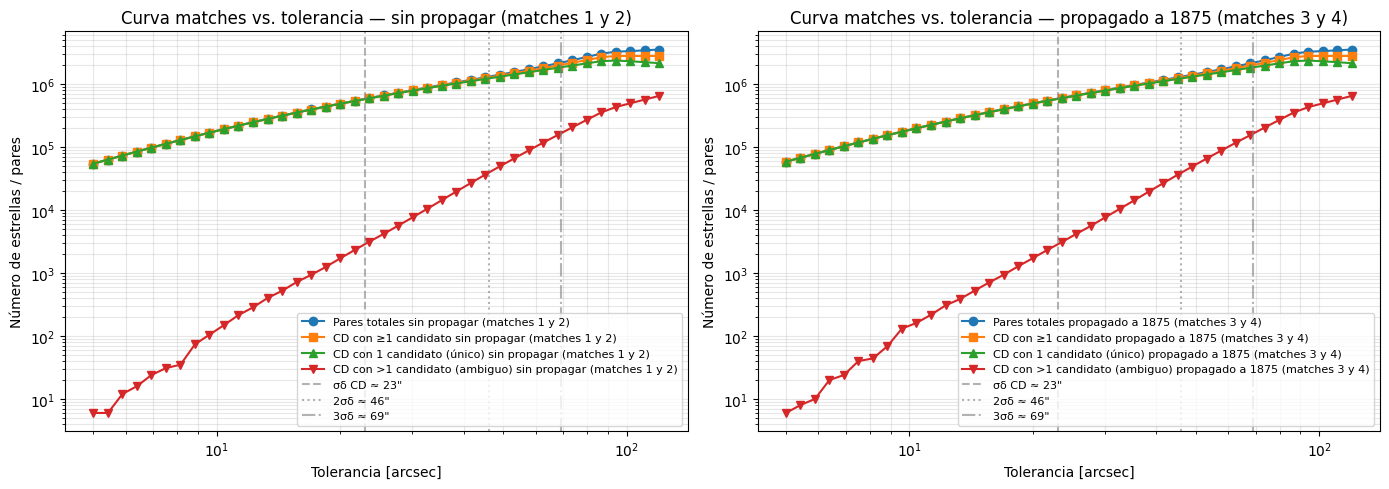

In [11]:
# Correr los dos análisis y graficarlos juntos para comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_2016 = estimar_tolerancia(
    cd_coords, gaia_coords_2016,
    label="sin propagar (matches 1 y 2)",
    ax=axes[0]
)

res_1875 = estimar_tolerancia(
    cd_coords, gaia_coords_1875,
    label="propagado a 1875 (matches 3 y 4)",
    ax=axes[1]
)

plt.show()

In [12]:
def distribucion_separaciones(
    cd_coords,
    gaia_coords,
    radio_maximo_arcsec=120,
    bins=100,
    label=""
):
    """
    Calcula y grafica la distribución de separaciones angulares entre
    todos los pares CD-Gaia dentro del radio máximo de búsqueda.
    La idea es identificar visualmente dónde termina la población de
    pares reales (pico) y dónde empieza la de falsos
    (cola).
    """
    idx_cd, idx_gaia, sep2d, _ = cd_coords.search_around_sky(
        gaia_coords, radio_maximo_arcsec * u.arcsec
    )
    sep_arcsec = sep2d.arcsec

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución de separaciones angulares — {label}')

    # Panel izquierdo: escala lineal
    mask_zoom = sep_arcsec <= 60
    ax[0].hist(sep_arcsec[mask_zoom], bins=bins, color='steelblue', edgecolor='none')
    ax[0].set_xlabel('Separación angular [arcsec]')
    ax[0].set_ylabel('Número de pares')
    ax[0].set_title('Zoom en los primeros 60" (escala lineal)')
    ax[0].grid(True, alpha=0.3)

    # Panel derecho: escala logarítmica
    ax[1].hist(sep_arcsec, bins=bins, color='steelblue', edgecolor='none')
    ax[1].set_xlabel('Separación angular [arcsec]')
    ax[1].set_ylabel('Número de pares')
    ax[1].set_yscale('log')
    ax[1].set_title('Rango completo (escala log)')
    ax[1].grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return sep_arcsec

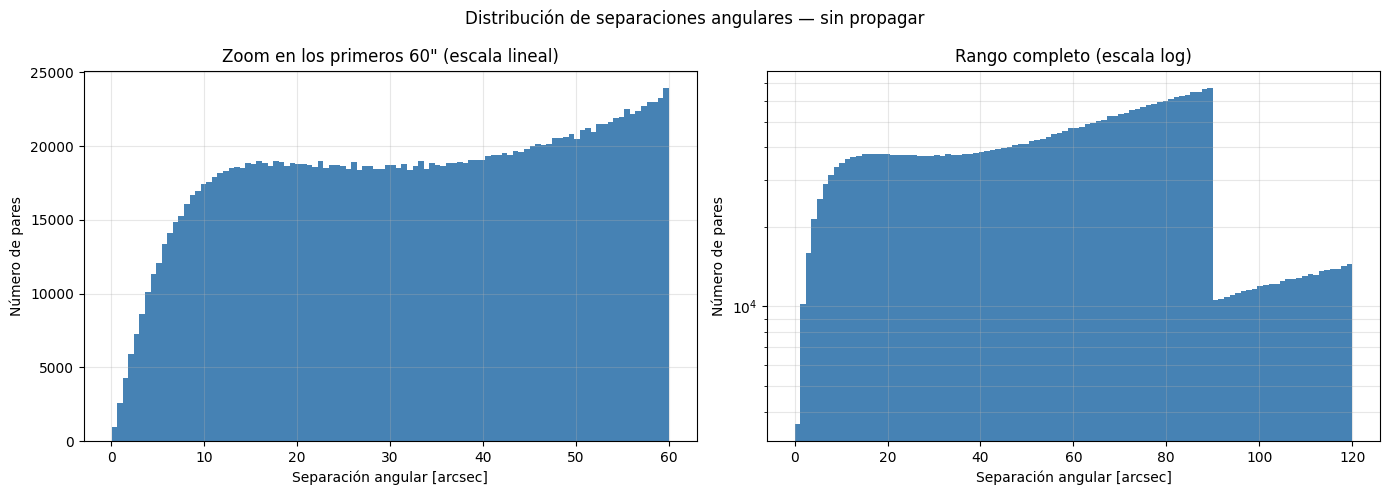

In [13]:
sep_2016 = distribucion_separaciones(
    cd_coords, gaia_coords_2016,
    radio_maximo_arcsec=120,
    label="sin propagar"
)

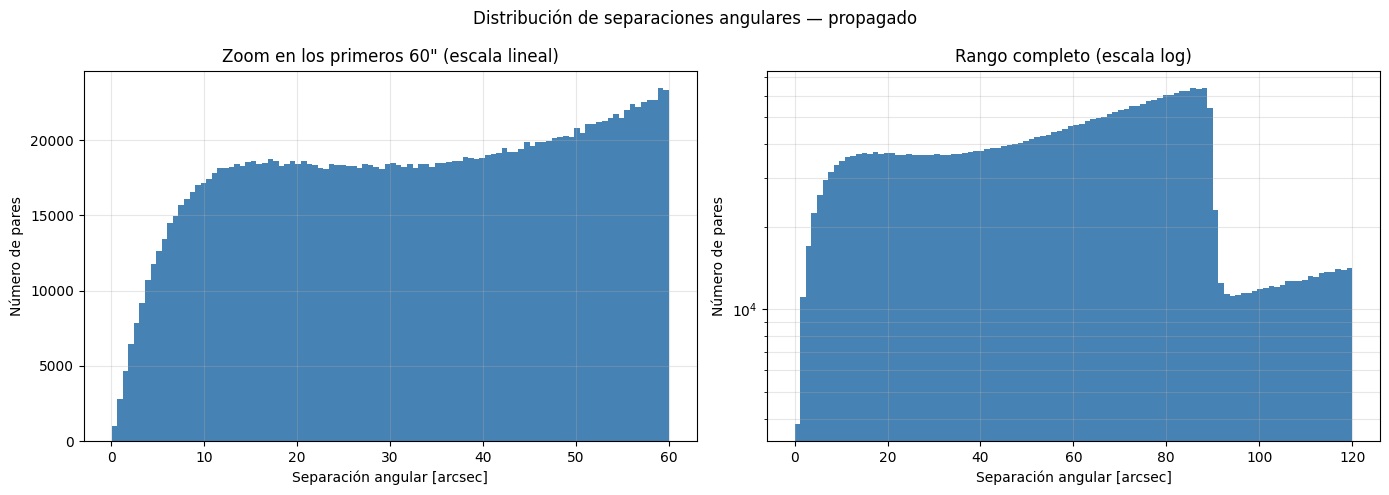

In [14]:
sep_1875 = distribucion_separaciones(
    cd_coords, gaia_coords_1875,
    radio_maximo_arcsec=120,
    label="propagado"
)